# Mantenimiento predictivo de rodamientos con series temporales — PHM IEEE 2012 (PRONOSTIA)

**Problema:** un rodamiento que falla sin aviso detiene la máquina (parada no planificada, cara).
**Objetivo:** a partir de la serie temporal de vibración (una captura cada 10 s), clasificar si el rodamiento
ya entró en su **zona de mantenimiento** (último 10 % de su vida útil) para programar el cambio antes de la falla.

**Métrica de éxito: F1 de la clase "mantenimiento"**, reportando también recall y precisión.
El recall solo no sirve: un modelo que siempre dice "mantenimiento" tiene recall 1 y es inútil. F1 exige
detectar la zona de riesgo (recall) sin inundar de falsas alarmas (precisión).

## 1. Carga de datos
Se usan los **17 rodamientos llevados hasta la falla**: `Learning_set` (6) y `Full_Test_Set` (11), ~2 GB.
Se descargan solo esas dos carpetas del repositorio (requiere `git`).

In [1]:
import os, glob, subprocess, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
from scipy.stats import kurtosis, skew
warnings.filterwarnings("ignore")

REPO = "https://github.com/wkzs111/phm-ieee-2012-data-challenge-dataset"
DATA_DIR = "data/phm2012"
CARPETAS = ["Learning_set", "Full_Test_Set"]

if not all(os.path.isdir(os.path.join(DATA_DIR, c)) for c in CARPETAS):
    if not os.path.isdir(DATA_DIR):
        subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none", "--sparse", REPO, DATA_DIR], check=True)
    subprocess.run(["git", "-C", DATA_DIR, "sparse-checkout", "set", *CARPETAS], check=True)

DIRS = sorted(glob.glob(os.path.join(DATA_DIR, "*", "Bearing*")), key=os.path.basename)
print(len(DIRS), "rodamientos:", [os.path.basename(d) for d in DIRS])

17 rodamientos: ['Bearing1_1', 'Bearing1_2', 'Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_1', 'Bearing2_2', 'Bearing2_3', 'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_1', 'Bearing3_2', 'Bearing3_3']


## 2. Indicadores por captura
Cada `acc_xxxxx.csv` tiene 2560 muestras (0,1 s a 25,6 kHz) de aceleración horizontal y vertical.
Cada captura se resume en 5 indicadores por eje: **RMS** (energía de vibración), **pico**, **curtosis** y
**asimetría** (impulsos que generan los defectos) y **factor de cresta** (pico/RMS).
Así ~64 millones de filas crudas se reducen a una tabla de ~24 900 filas (una por captura).

In [2]:
def indicadores(x):
    rms = np.sqrt(np.mean(x**2)); pico = np.max(np.abs(x))
    return {"rms": rms, "pico": pico, "curtosis": kurtosis(x), "asimetria": skew(x), "factor_cresta": pico / rms}

def leer_captura(f):
    try:
        return np.loadtxt(f, delimiter=",", usecols=(4, 5))
    except ValueError:                      # algunos rodamientos usan ';' como separador
        return np.loadtxt(f, delimiter=";", usecols=(4, 5))

CACHE = "features_cache.csv"
if os.path.exists(CACHE):
    df = pd.read_csv(CACHE)
else:
    filas = []
    for d in DIRS:
        b = os.path.basename(d); archivos = sorted(glob.glob(os.path.join(d, "acc_*.csv"))); n = len(archivos)
        for i, f in enumerate(archivos):
            x = leer_captura(f)
            r = {"rodamiento": b, "condicion": "C" + b[7], "t_min": i * 10 / 60,
                 "rul_min": (n - 1 - i) * 10 / 60, "vida_frac": i / (n - 1)}
            for eje, k in ((0, "h"), (1, "v")):
                r.update({f"{nom}_{k}": v for nom, v in indicadores(x[:, eje]).items()})
            filas.append(r)
    df = pd.DataFrame(filas); df.to_csv(CACHE, index=False)

print(df.shape)
df.groupby("rodamiento").agg(condicion=("condicion", "first"), capturas=("t_min", "size"), vida_horas=("t_min", lambda s: round(s.max() / 60, 2)))

(24889, 15)


,condicion,capturas,vida_horas
rodamiento,,,
Bearing1_1,C1,2803,7.78
Bearing1_2,C1,871,2.42
Bearing1_3,C1,2375,6.59
Bearing1_4,C1,1428,3.96
Bearing1_5,C1,2463,6.84
Bearing1_6,C1,2448,6.80
Bearing1_7,C1,2259,6.27
Bearing2_1,C2,911,2.53
Bearing2_2,C2,797,2.21


## 3. Features de serie temporal
Una captura aislada es ruidosa y no dice hacia dónde va el rodamiento. Por eso cada fila se describe con su
**historia reciente**, calculada por rodamiento y **solo con el pasado** (ventanas móviles causales: nunca se usa
información futura, igual que en operación real):

| Feature | Qué mide | Por qué |
|---|---|---|
| `_m6` | media móvil de 1 min (6 capturas) | suaviza el ruido |
| `_m30` | media móvil de 5 min | nivel de fondo más estable |
| `_rel` | `_m6` / mínimo histórico de `_m30` | compara con el propio estado sano (cada rodamiento vibra distinto) |
| `_tend` | cambio de `_m6` en los últimos 5 min | velocidad de degradación |
| `_std30` | desvío estándar en 5 min | inestabilidad de la señal |
| `t_horas` | horas de operación acumuladas | edad del rodamiento (dato que siempre se conoce en planta) |

In [3]:
SENALES = ["rms_h", "rms_v", "pico_h", "pico_v", "curtosis_h", "curtosis_v", "factor_cresta_h", "factor_cresta_v"]

def features_temporales(df):
    df = df.sort_values(["rodamiento", "t_min"]).reset_index(drop=True)
    for c in SENALES:
        g = df.groupby("rodamiento")[c]
        df[f"{c}_m6"] = g.transform(lambda s: s.rolling(6, min_periods=1).mean())
        df[f"{c}_m30"] = g.transform(lambda s: s.rolling(30, min_periods=1).mean())
        df[f"{c}_rel"] = df[f"{c}_m6"] / df.groupby("rodamiento")[f"{c}_m30"].cummin()
        df[f"{c}_tend"] = df.groupby("rodamiento")[f"{c}_m6"].diff(30).fillna(0)
        df[f"{c}_std30"] = g.transform(lambda s: s.rolling(30, min_periods=2).std()).fillna(0)
    df["t_horas"] = df["t_min"] / 60
    return df

df = features_temporales(df)
NUM = [f"{c}_{s}" for s in ("m6", "m30", "rel", "tend", "std30") for c in SENALES] + ["t_horas"]
CAT = ["condicion"]      # condición de operación: C1 1800 rpm/4000 N, C2 1650 rpm/4200 N, C3 1500 rpm/5000 N
df["mantenimiento"] = (df["vida_frac"] >= 0.9).astype(int)   # etiqueta: último 10 % de vida
print(len(NUM), "features numéricas"); df["mantenimiento"].value_counts()

41 features numéricas


mantenimiento
0    22391
1     2498
Name: count, dtype: int64

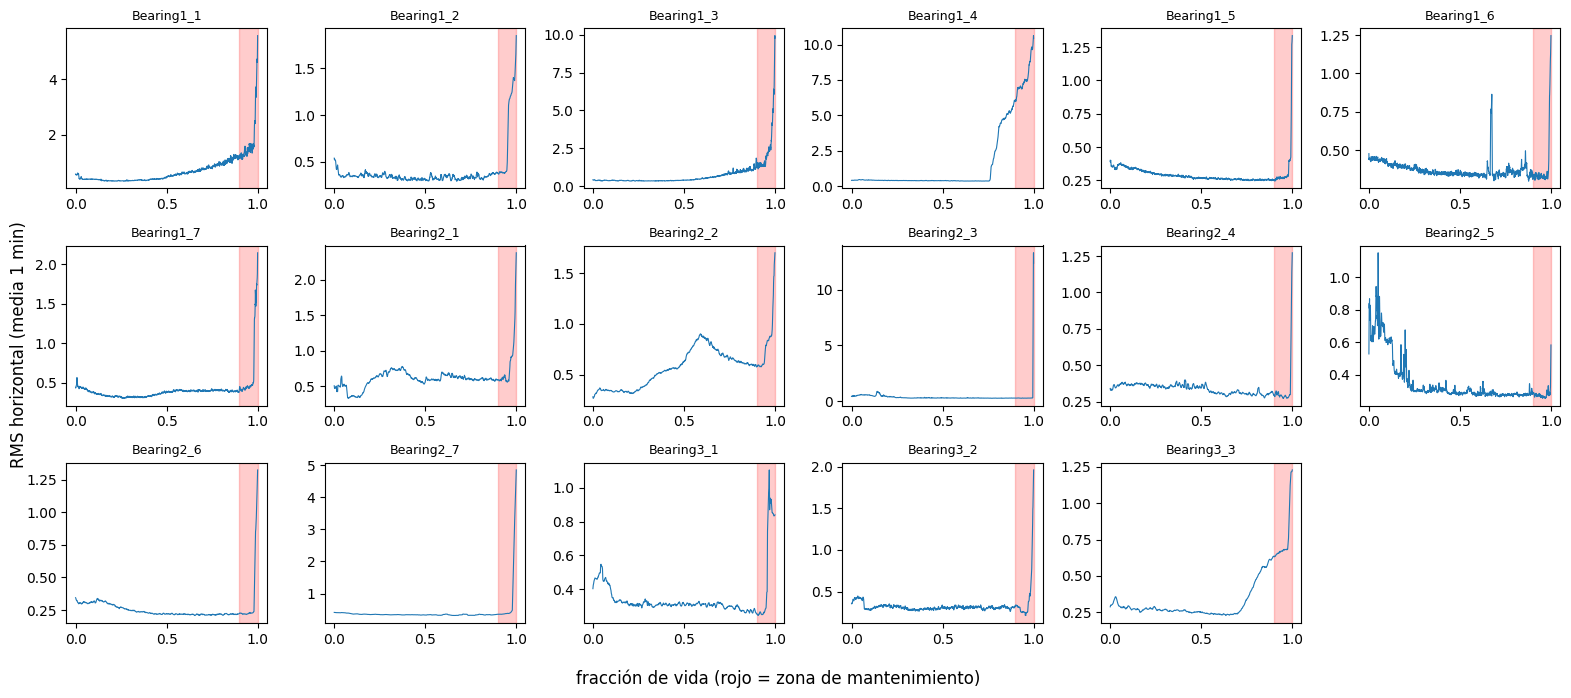

In [4]:
fig, axs = plt.subplots(3, 6, figsize=(16, 7)); axs = axs.ravel()
for ax, (b, d) in zip(axs, df.groupby("rodamiento")):
    ax.plot(d.vida_frac, d.rms_h_m6, lw=.8); ax.axvspan(0.9, 1, color="red", alpha=.2); ax.set_title(b, fontsize=9)
axs[-1].axis("off"); fig.supxlabel("fracción de vida (rojo = zona de mantenimiento)"); fig.supylabel("RMS horizontal (media 1 min)")
plt.tight_layout(); plt.show()

## 4. Split train/test por rodamiento
En series temporales no se mezclan capturas al azar: dos capturas vecinas son casi iguales y el test quedaría
"contaminado". Se separan **rodamientos completos** con `GroupShuffleSplit` (25 % para test, semilla fija).

In [5]:
from sklearn.model_selection import GroupShuffleSplit
idx_train, idx_test = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42).split(df, groups=df.rodamiento))
train, test = df.iloc[idx_train], df.iloc[idx_test]
X_train, y_train, g_train = train[NUM + CAT], train["mantenimiento"], train["rodamiento"]
X_test,  y_test = test[NUM + CAT], test["mantenimiento"]
print("Train:", sorted(train.rodamiento.unique()))
print("Test: ", sorted(test.rodamiento.unique()))

Train: ['Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_7', 'Bearing2_1', 'Bearing2_2', 'Bearing2_3', 'Bearing2_4', 'Bearing2_6', 'Bearing2_7', 'Bearing3_1', 'Bearing3_3']
Test:  ['Bearing1_1', 'Bearing1_2', 'Bearing1_6', 'Bearing2_5', 'Bearing3_2']


## 5. Selección del modelo (validación cruzada por rodamiento)
Todos los candidatos usan **el mismo `Pipeline`**: `ColumnTransformer` (escalado de numéricas + one-hot de la
condición) → clasificador. Se comparan con `GroupKFold` (5 folds, cada fold deja fuera rodamientos enteros),
**solo con datos de train**; el test no se toca hasta el final.

| Modelo | Por qué se prueba |
|---|---|
| `DummyClassifier` | línea base: predice al azar respetando la proporción de clases. Cualquier modelo útil debe superarlo. |
| `LogisticRegression` | modelo lineal, simple e interpretable. |
| `RandomForestClassifier` | muchos árboles de decisión con votación; capta relaciones no lineales entre features. |
| `HistGradientBoostingClassifier` | árboles entrenados en secuencia, cada uno corrige los errores del anterior. |
| `RandomForest` **sin** features temporales | control: mide cuánto aportan las series temporales. |

Los modelos con `class_weight="balanced"` dan más peso a la clase minoritaria (solo ~10 % es mantenimiento).

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import f1_score, recall_score, precision_score

def crear_pipeline(clf, num=NUM):
    pre = ColumnTransformer([("num", StandardScaler(), num),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])
    return Pipeline([("preproceso", pre), ("clf", clf)])

candidatos = {
    "Dummy (azar)": (DummyClassifier(strategy="stratified", random_state=42), NUM),
    "LogisticRegression": (LogisticRegression(max_iter=3000, class_weight="balanced"), NUM),
    "RandomForest": (RandomForestClassifier(n_estimators=300, min_samples_leaf=10, class_weight="balanced",
                                            random_state=42, n_jobs=-1), NUM),
    "HistGradientBoosting": (HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05,
                                                            class_weight="balanced", random_state=42), NUM),
    "RandomForest sin series temporales": (RandomForestClassifier(n_estimators=300, min_samples_leaf=10,
                                           class_weight="balanced", random_state=42, n_jobs=-1), SENALES),
}
filas = []
for nombre, (clf, cols) in candidatos.items():
    y_cv = cross_val_predict(crear_pipeline(clf, cols), train[cols + CAT], y_train, groups=g_train, cv=GroupKFold(5))
    filas.append({"modelo": nombre, "F1": f1_score(y_train, y_cv), "recall": recall_score(y_train, y_cv),
                  "precision": precision_score(y_train, y_cv)})
comparacion = pd.DataFrame(filas).sort_values("F1", ascending=False).round(3)
comparacion

,modelo,F1,recall,precision
2,RandomForest,0.513,0.620,0.437
3,HistGradientBoosting,0.473,0.655,0.370
1,LogisticRegression,0.448,0.747,0.320
4,RandomForest sin series temporales,0.291,0.425,0.222
0,Dummy (azar),0.089,0.089,0.089


In [7]:
# Se elige el mejor F1 entre los que usan series temporales
MEJOR = comparacion[comparacion.modelo != "RandomForest sin series temporales"].iloc[0].modelo
print("Modelo elegido:", MEJOR)

Modelo elegido: RandomForest


## 6. Entrenamiento final y evaluación sobre test

In [8]:
clf, cols = candidatos[MEJOR]
modelo = crear_pipeline(clf, cols).fit(X_train, y_train)
modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproceso', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["normal", "mantenimiento"]))
print(pd.DataFrame(confusion_matrix(y_test, y_pred), index=["real normal", "real mant."], columns=["pred normal", "pred mant."]))
REC, PREC, F1 = recall_score(y_test, y_pred), precision_score(y_test, y_pred), f1_score(y_test, y_pred)

               precision    recall  f1-score   support

       normal       0.97      0.90      0.93      9060
mantenimiento       0.46      0.77      0.57      1010

     accuracy                           0.89     10070
    macro avg       0.71      0.83      0.75     10070
 weighted avg       0.92      0.89      0.90     10070

             pred normal  pred mant.
real normal         8138         922
real mant.           234         776


**Evaluación como se usaría en planta:** se lanza una alarma cuando 3 capturas seguidas (30 s) superan
probabilidad 0,5, y se mide cuánto antes de la falla llega el aviso.

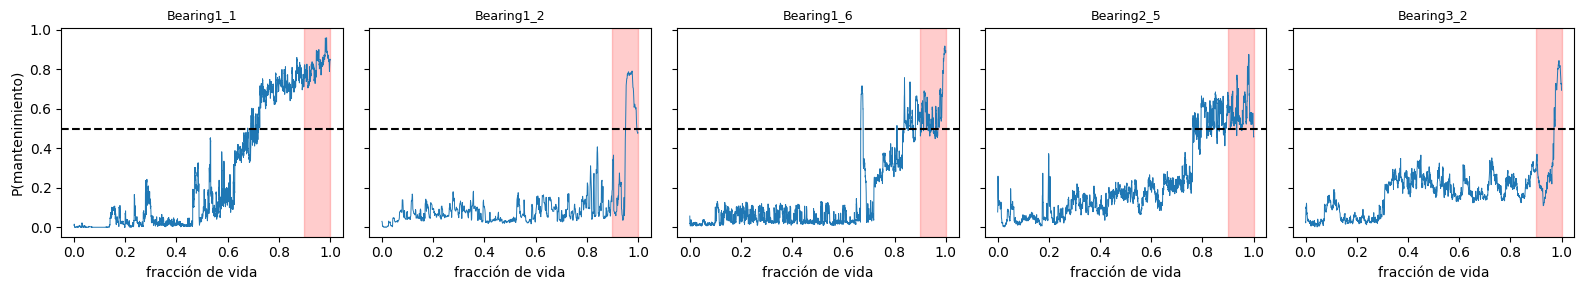

,rodamiento,vida_horas,alarma_en_%_vida,minutos_de_aviso
0,Bearing1_1,7.78,69,144
1,Bearing1_2,2.42,95,7
2,Bearing1_6,6.80,67,135
3,Bearing2_5,6.42,76,91
4,Bearing3_2,4.54,97,8


In [10]:
test = test.assign(prob=modelo.predict_proba(X_test)[:, 1])
fig, axs = plt.subplots(1, test.rodamiento.nunique(), figsize=(16, 3), sharey=True)
alarmas = []
for ax, (b, d) in zip(axs, test.groupby("rodamiento")):
    ax.plot(d.vida_frac, d.prob, lw=.7); ax.axvspan(0.9, 1, color="red", alpha=.2); ax.axhline(.5, ls="--", c="k")
    ax.set_title(b, fontsize=9); ax.set_xlabel("fracción de vida")
    alarma = (d.prob > .5).astype(int).rolling(3).sum().eq(3)
    r = d.loc[alarma.idxmax()] if alarma.any() else None
    alarmas.append({"rodamiento": b, "vida_horas": round(d.t_min.max() / 60, 2),
                    "alarma_en_%_vida": None if r is None else round(100 * r.vida_frac),
                    "minutos_de_aviso": None if r is None else round(r.rul_min)})
axs[0].set_ylabel("P(mantenimiento)"); plt.tight_layout(); plt.show()
pd.DataFrame(alarmas)

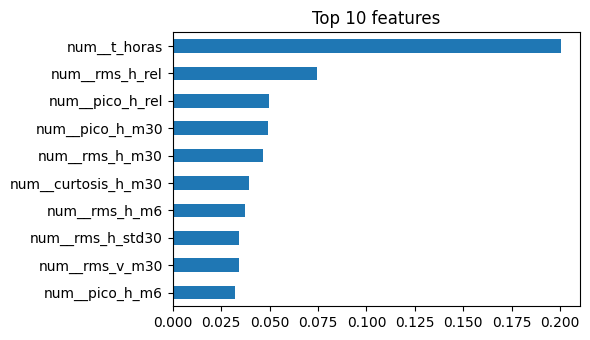

In [11]:
# ¿Qué features usa más el modelo?
imp = getattr(modelo.named_steps["clf"], "feature_importances_", None)
if imp is not None:
    nombres = modelo.named_steps["preproceso"].get_feature_names_out()
    pd.Series(imp, index=nombres).sort_values(ascending=False).head(10).plot.barh(figsize=(6, 3.5)).invert_yaxis()
    plt.title("Top 10 features"); plt.tight_layout(); plt.show()

## 7. ROI estimado (3 escenarios)
Supuestos por rodamiento que llega al final de su vida (**costos ilustrativos**, USD; flota de 100 rodamientos/año):
- Sin modelo: toda falla es no planificada → `costo_falla`.
- Con modelo: se detecta con probabilidad ≈ recall → cambio planificado `costo_plan`; si no, `costo_falla`.
- Falsas alarmas por detección ≈ (1 − precisión)/precisión, cada una cuesta una inspección.
- `costo_sistema`: sensores + software por año.

In [12]:
N = 100
escenarios = {
    "Conservador": dict(costo_falla=2000,  costo_plan=500, costo_inspeccion=100, costo_sistema=30000),
    "Base":        dict(costo_falla=5000,  costo_plan=500, costo_inspeccion=100, costo_sistema=30000),
    "Optimista":   dict(costo_falla=10000, costo_plan=500, costo_inspeccion=100, costo_sistema=30000),
}
filas = []
for nombre, e in escenarios.items():
    sin_modelo = N * e["costo_falla"]
    detectadas = REC * N
    falsas = detectadas * (1 - PREC) / PREC
    con_modelo = (detectadas * e["costo_plan"] + (N - detectadas) * e["costo_falla"]
                  + falsas * e["costo_inspeccion"] + e["costo_sistema"])
    ahorro = sin_modelo - con_modelo
    filas.append({"escenario": nombre, "costo_falla": e["costo_falla"], "costo_sin_modelo": sin_modelo,
                  "costo_con_modelo": round(con_modelo), "ahorro": round(ahorro),
                  "ROI_%": round(100 * ahorro / e["costo_sistema"])})
pd.DataFrame(filas)

,escenario,costo_falla,costo_sin_modelo,costo_con_modelo,ahorro,ROI_%
0,Conservador,2000,200000,123881,76119,254
1,Base,5000,500000,193386,306614,1022
2,Optimista,10000,1000000,309228,690772,2303


## 8. Guardar y recargar el modelo con `joblib`

In [13]:
joblib.dump(modelo, "model.pkl")
modelo_cargado = joblib.load("model.pkl")
print("Predicciones idénticas:", (modelo_cargado.predict(X_test) == y_pred).all())

Predicciones idénticas: True


## 9. Muestra de datos (100 filas) para la app
70 filas normales + 30 de mantenimiento, tomadas de los rodamientos de test (la proporción real es ~10 %; se sobre-representa la clase de alarma para la demo).

In [14]:
muestra = pd.concat([test[test.mantenimiento == 0].sample(70, random_state=42),
                     test[test.mantenimiento == 1].sample(30, random_state=42)]).sort_values(["rodamiento", "t_min"])
cols_muestra = ["rodamiento", "condicion", "t_min", "rul_min", "vida_frac"] + NUM + ["mantenimiento"]
muestra[cols_muestra].to_csv("datos_muestra.csv", index=False)
print(muestra[cols_muestra].shape)

(100, 47)


## Conclusiones y próximos pasos
- Las features de serie temporal son las que hacen funcionar al modelo: el mismo RandomForest sin ellas rinde bastante peor en validación.
- El modelo elegido avisa antes de la falla en los rodamientos de test, aunque todavía con falsas alarmas.
- Próximos pasos: (1) features de frecuencia (FFT / envolvente en frecuencias de falla),
  (2) ajustar el umbral de alarma según el costo real de una falsa alarma,
  (3) regresión de vida útil remanente (RUL) con modelos secuenciales (LSTM).